In [1]:
from pyns.nsfile import NSFile
from pathlib import Path
import numpy as np
import pandas as pd
import smile_extract
import seaborn as sns
from src.process_ripple import compose_ripple_smile

In [ ]:
monkey = "Sulley"
date = "2025-10-03"
task = "automonkey-stim"
folder = Path(f"/Users/raeed/Library/CloudStorage/OneDrive-UniversityofPittsburgh/0-projects/miso-setup/data/{monkey}/{date}")
nev_filename = folder / f"{monkey}_{date}_{task}_neural.nev"
smile_file = folder / f"{monkey}_{date}_{task}_behavior.mat"
nsfile = NSFile(str(nev_filename))
smile_data = smile_extract.direct_load_smile_data(str(smile_file))

In [6]:
trialframe = compose_ripple_smile(nsfile,smile_data,bin_size='1ms')
trialframe

recorded channel                                                        M1.chan001  \
trial_id time                   stim trial state    stimulated channel               
1        0 days 00:00:00        False      pre-move -1                           0   
         0 days 00:00:00.001000 False      pre-move -1                           0   
         0 days 00:00:00.002000 False      pre-move -1                           0   
         0 days 00:00:00.003000 False      pre-move -1                           0   
         0 days 00:00:00.004000 False      pre-move -1                           0   
...                                                                            ...   
1031     0 days 00:00:01.861000 False      success  -1                           0   
         0 days 00:00:01.862000 False      success  -1                           0   
         0 days 00:00:01.863000 False      success  -1                           0   
         0 days 00:00:01.864000 False      success  -1                           0   
         0 days 00:00:01.865000 False      end      -1                           0   

recorded channel                                                        M1.chan002  \
trial_id time                   stim trial state    stimulated channel               
1        0 days 00:00:00        False      pre-move -1                           1   
         0 days 00:00:00.001000 False      pre-move -1                           0   
         0 days 00:00:00.002000 False      pre-move -1                           0   
         0 days 00:00:00.003000 False      pre-move -1                           0   
         0 days 00:00:00.004000 False      pre-move -1                           0   
...                                                                            ...   
1031     0 days 00:00:01.861000 False      success  -1                           0   
         0 days 00:00:01.862000 False      success  -1                           0   
         0 days 00:00:01.863000 False      success  -1                           0   
         0 days 00:00:01.864000 False      success  -1                           0   
         0 days 00:00:01.865000 False      end      -1                           0   

recorded channel                                                        M1.chan003  \
trial_id time                   stim trial state    stimulated channel               
1        0 days 00:00:00        False      pre-move -1                           0   
         0 days 00:00:00.001000 False      pre-move -1                           0   
         0 days 00:00:00.002000 False      pre-move -1                           0   
         0 days 00:00:00.003000 False      pre-move -1                           0   
         0 days 00:00:00.004000 False      pre-move -1                           0   
...                                                                            ...   
1031     0 days 00:00:01.861000 False      success  -1                           0   
         0 days 00:00:01.862000 False      success  -1                           0   
         0 days 00:00:01.863000 False      success  -1                           0   
         0 days 00:00:01.864000 False      success  -1                           0   
         0 days 00:00:01.865000 False      end      -1                           0   

recorded channel                                                        M1.chan004  \
trial_id time                   stim trial state    stimulated channel               
1        0 days 00:00:00        False      pre-move -1                           0   
         0 days 00:00:00.001000 False      pre-move -1                           0   
         0 days 00:00:00.002000 False      pre-move -1                           0   
         0 days 00:00:00.003000 False      pre-move -1                           0   
         0 days 00:00:00.004000 False      pre-move -1                           0   
...                                      

pass
False    82
True     46
Name: count, dtype: int64

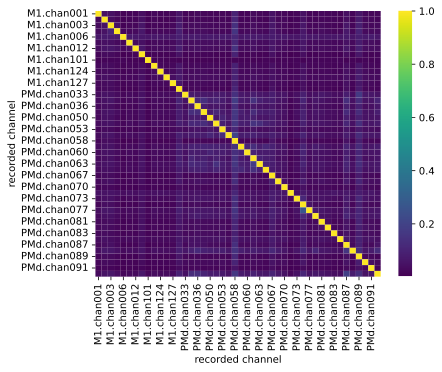

In [7]:
from src.process_ripple import get_channel_stats
spike_mat = (
    trialframe
    .xs(level='stim trial',key=False)
)
channel_stats = get_channel_stats(spike_mat)
spike_mat_select = (
    spike_mat
    .loc[:, channel_stats.index[channel_stats['pass']]]
)
select_coincidence = (
    (spike_mat_select.T @ spike_mat_select)
    / spike_mat_select.sum(axis=0)
)
sns.heatmap(select_coincidence, cmap='viridis')
channel_stats['pass'].value_counts()

In [8]:
from src.time_slice import get_epoch_data
stim_response = (
    trialframe
    [channel_stats.index[channel_stats['pass']]]
    .pipe(get_epoch_data,{
        # for some reason, the stim event is around 85ms after the actual stim time
        'pre-stim': ('stim',slice(pd.to_timedelta('-250ms'),pd.to_timedelta('-100ms'))),
        'post-stim': ('stim',slice(pd.to_timedelta('150ms'),pd.to_timedelta('300ms'))),
    })
    .div(1e-3)  # convert to firing rate in Hz
    .groupby(['trial_id','stimulated channel','phase'])
    .mean()
)
stim_response

recorded channel                       M1.chan001  M1.chan002  M1.chan003  \
trial_id stimulated channel phase                                           
1        -1                 post-stim    6.622517    6.622517    0.000000   
                            pre-stim    13.245033    6.622517    0.000000   
2        -1                 post-stim    6.622517    6.622517    0.000000   
                            pre-stim     0.000000    6.622517    6.622517   
3        -1                 post-stim    0.000000   13.245033    0.000000   
...                                           ...         ...         ...   
1029     M1.chan009         pre-stim     6.622517    0.000000    6.622517   
1030     -1                 post-stim   19.867550   13.245033   13.245033   
                            pre-stim     0.000000   14.084507    0.000000   
1031     -1                 post-stim   13.245033    6.622517    6.622517   
                            pre-stim   139.072848  145.695364  198.675497   

recorded channel                       M1.chan005  M1.chan006  M1.chan009  \
trial_id stimulated channel phase                                           
1        -1                 post-stim    6.622517   66.225166   19.867550   
                            pre-stim     0.000000   92.715232    6.622517   
2        -1                 post-stim   13.245033   59.602649   19.867550   
                            pre-stim    13.245033   66.225166   26.490066   
3        -1                 post-stim    6.622517   79.470199    6.622517   
...                                           ...         ...         ...   
1029     M1.chan009         pre-stim     0.000000   59.602649    6.622517   
1030     -1                 post-stim   26.490066   33.112583    0.000000   
                            pre-stim    14.084507   42.253521    0.000000   
1031     -1                 post-stim    0.000000   52.980132    6.622517   
                            pre-stim   211.920530  139.072848  145.695364   

recorded channel                       M1.chan012  M1.chan017  M1.chan101  \
trial_id stimulated channel phase                                           
1        -1                 post-stim   19.867550    0.000000   26.490066   
                            pre-stim    13.245033    6.622517   19.867550   
2        -1                 post-stim   19.867550   19.867550   19.867550   
                            pre-stim    39.735099    0.000000   19.867550   
3        -1                 post-stim   13.245033   13.245033   13.245033   
...                                           ...         ...         ...   
1029     M1.chan009         pre-stim    19.867550    0.000000   13.245033   
1030     -1                 post-stim   19.867550    0.000000    6.622517   
                            pre-stim    28.169014    7.042254   28.169014   
1031     -1                 post-stim    6.622517    0.000000    6.622517   
                            pre-stim   178.807947  145.695364   26.490066   

recorded channel                       M1.chan122  ...  PMd.chan081  \
trial_id stimulated channel phase                  ...                
1        -1                 post-stim    6.622517  ...    13.245033   
                            pre-stim     6.622517  ...     0.000000   
2        -1                 post-stim    6.622517  ...     0.000000   
                            pre-stim    33.112583  ...    19.867550   
3        -1                 post-stim   19.867550  ...     0.000000   
...                                           ...  ...          ...   
1029     M1.chan009         pre-stim     6.622517  ...     0.000000   
1030     -1                 post-stim   13.245033  ...     0.000000   
                            pre-stim     7.042254  ...     7.042254   
1031     -1                 post-stim    6.622517  ...    26.490066   
                            pre-stim   132.450331  ...   165.562914   

recorded channel                       PMd.chan082  PMd.chan083  PMd.c

In [9]:
post_stim = stim_response.xs('post-stim',level='phase')
pre_stim = stim_response.xs('pre-stim',level='phase')
stim_change = (post_stim - pre_stim) # change this to z-score by the non-stim trials

null_stim_response = (
    stim_change
    .xs(level='stimulated channel',key=-1)
)

norm_stim_response = (
    stim_change
    .loc[lambda df: df.index.get_level_values('stimulated channel') != -1]
    .sub(null_stim_response.mean())
    .div(null_stim_response.std())
)
import altair as alt
temp = (
    norm_stim_response
    .stack()
    .to_frame('stimulation response (z-score)') # type: ignore
    .groupby(['stimulated channel','recorded channel'])
    .mean()
    .reset_index()
)
alt.Chart(temp).mark_rect().encode(
    x=alt.X('recorded channel:N', title='Recorded Channel'),
    y=alt.Y('stimulated channel:N', title='Stimulated Channel'),
    color=alt.Color('stimulation response (z-score):Q', scale=alt.Scale(scheme='redblue', domainMid=0, reverse=True, domain=[-2.5,1.5]), title='Z-scored Change in Firing Rate'),
    tooltip=['stimulated channel', 'recorded channel', 'stimulation response (z-score)']
).properties(
    width=400,
    height=400,
)

alt.Chart(...)

In [10]:
from src.process_ripple import read_map
electrode_map = (
    read_map(Path('../data/sulley/sulley_SN_4566-004410.map'))
    [['x','y']]
    .sort_index()
)
example_stim_response = (
    norm_stim_response
    .xs(key='PMd.chan040',level='stimulated channel')
    .stack()
    .to_frame('stimulation response (z-score)') # type: ignore
    .groupby('recorded channel')
    .mean()
    .join(electrode_map, how='left')
    .reset_index()
)
alt.Chart(example_stim_response).mark_rect().encode(
    x=alt.X('x:O', title='X Coordinate'),
    y=alt.Y('y:O', title='Y Coordinate'),
    color=alt.Color('stimulation response (z-score):Q', scale=alt.Scale(scheme='redblue', domainMid=0, reverse=True, domain=[-2.5,1.5]), title='Z-scored Change in Firing Rate'),
    tooltip=['recorded channel', 'stimulation response (z-score)', 'x', 'y']
).properties(
    width=800,
    height=400,
)

alt.Chart(...)

In [11]:
stim_raster = (
    trialframe
    [channel_stats.index[channel_stats['pass']]]
    .pipe(get_epoch_data,{
        # for some reason, the stim event is around 85ms after the actual stim time
        'peri-stim': ('stim',slice(pd.to_timedelta('-250ms'),pd.to_timedelta('300ms'))),
    })
)
stim_raster

recorded channel                                                                        M1.chan001  \
trial_id time                     stim trial state        stimulated channel phase                   
1        -1 days +23:59:59.750000 False      target onset -1                 peri-stim           0   
         -1 days +23:59:59.751000 False      target onset -1                 peri-stim           0   
         -1 days +23:59:59.752000 False      target onset -1                 peri-stim           0   
         -1 days +23:59:59.753000 False      target onset -1                 peri-stim           0   
         -1 days +23:59:59.754000 False      target onset -1                 peri-stim           0   
...                                                                                            ...   
1031     0 days 00:00:00.296000   False      stim         -1                 peri-stim           0   
         0 days 00:00:00.297000   False      stim         -1                 peri-stim           0   
         0 days 00:00:00.298000   False      stim         -1                 peri-stim           0   
         0 days 00:00:00.299000   False      stim         -1                 peri-stim           1   
         0 days 00:00:00.300000   False      stim         -1                 peri-stim           0   

recorded channel                                                                        M1.chan002  \
trial_id time                     stim trial state        stimulated channel phase                   
1        -1 days +23:59:59.750000 False      target onset -1                 peri-stim           0   
         -1 days +23:59:59.751000 False      target onset -1                 peri-stim           0   
         -1 days +23:59:59.752000 False      target onset -1                 peri-stim           0   
         -1 days +23:59:59.753000 False      target onset -1                 peri-stim           1   
         -1 days +23:59:59.754000 False      target onset -1                 peri-stim           0   
...                                                                                            ...   
1031     0 days 00:00:00.296000   False      stim         -1                 peri-stim           0   
         0 days 00:00:00.297000   False      stim         -1                 peri-stim           0   
         0 days 00:00:00.298000   False      stim         -1                 peri-stim           0   
         0 days 00:00:00.299000   False      stim         -1                 peri-stim           0   
         0 days 00:00:00.300000   False      stim         -1                 peri-stim           0   

recorded channel                                                                        M1.chan003  \
trial_id time                     stim trial state        stimulated channel phase                   
1        -1 days +23:59:59.750000 False      target onset -1                 peri-stim           0   
         -1 days +23:59:59.751000 False      target onset -1                 peri-stim           0   
         -1 days +23:59:59.752000 False      target onset -1                 peri-stim           0   
         -1 days +23:59:59.753000 False      target onset -1                 peri-stim           0   
         -1 days +23:59:59.754000 False      target onset -1                 peri-stim           0   
...                                                                                            ...   
1031     0 days 00:00:00.296000   False      stim         -1                 peri-stim           0   
         0 days 00:00:00.297000   False      stim         -1                 peri-stim           0   
         0 days 00:00:00.298000   False      stim         -1                 peri-stim           0   
         0 days 00:00:00.299000   False      stim         -1                 peri-stim           0   
         0 days 00:00:00.300000   False      stim         -1                 peri-stim           0   

recorded channel   

In [12]:
def plot_raster(stim_chan_label, rec_chan_label):
    raster = (
        alt.Chart(
            stim_raster
            [rec_chan_label]
            .xs(level='stimulated channel',key=stim_chan_label)
            .reset_index()
            .loc[lambda df: df[rec_chan_label]>0]
            .assign(**{
                'time': lambda df: df['time'].dt.total_seconds()
            })
        )
        .mark_tick()
        .encode(
            x='time:Q',
            y='trial_id:O'
        )
    )
    return raster

plot_raster('PMd.chan040', 'M1.chan006') & plot_raster('PMd.chan052', 'M1.chan126')

alt.VConcatChart(...)

In [13]:
from src.process_ripple import process_neural_data, trialize_timestamps, get_trial_starts
_, stim_table = process_neural_data(nsfile)

In [14]:
from pyns.nsentity import EntityType
from scipy.signal import butter, sosfiltfilt
stim_chan_label = 'PMd.chan052'
rec_chan_label = 'M1.chan126'

trial_starts = get_trial_starts(nsfile)
stim_times = (
    stim_table
    .pipe(trialize_timestamps, trial_starts)
    .groupby('trial_id')
    .first()
    .set_index('channel', append=True)
)
chan_stims = (
    stim_times
    .xs(level='channel', key=stim_chan_label)
    .assign(timestamp=lambda df: df['timestamp'] + df.index.get_level_values('trial_id').map(trial_starts))
    ['timestamp']
    .apply(lambda ts: ts.total_seconds())
)

chan_signal = [e for e in nsfile.get_entities(EntityType.analog) if e.label == f'{rec_chan_label} raw'][0]
signal_bins = chan_signal.get_index_by_time(1)
raw_signal = chan_signal.get_analog_data(
    start_index=chan_signal.get_index_by_time(chan_stims.values[3]-0.16), # 160 milliseconds before stim
    index_count=chan_signal.get_index_by_time(0.55), # 550 millisecond of data
)

# import matplotlib.pyplot as plt
# fig,ax = plt.subplots(1,1,figsize=(15,5))
# ax = sns.lineplot(lfp_data,ax=ax)
# ax.set_ylim(-200,200)

sos = butter(4, 250, fs=chan_signal.sample_freq, btype='highpass', output='sos')
filt_signal = sosfiltfilt(sos, raw_signal)

fig,ax = plt.subplots(1,1,figsize=(9,3))
ax.plot(np.linspace(-0.25,0.30,len(filt_signal)),filt_signal,color='0.3')
ax.set_ylim(-100,100)
ax.set_xlabel('time (s)')
ax.set_ylabel('filtered signal (uV)')

IndexError: list index out of range

In [ ]:
from src.impedance import load_and_process_impedance
# Parse the impedance file using the new module
impedance_filename = folder / "Sulley_2025-10-03_impedance.txt"
impedances = (
    load_and_process_impedance(impedance_filename)
    .groupby('Elec')
    ['Mag_kOhms']
    .mean()
    .rename('impedance (kOhms)')
    .rename_axis('channel')
    .to_frame()
    .assign(**{'pass': channel_stats['pass']})
)
sns.displot(
    data=impedances,
    x='impedance (kOhms)',
    hue='pass',
    log_scale=True,
)

In [ ]:
' '.join([
    str.replace('chan00','').replace('chan0','').replace('chan','')
    for str in channel_stats.index[channel_stats['pass']]
])